# Eesti pensionifondide valitsejate kulud (2025)

**Allikad:**
- Iga fondivalitseja **2025. aasta majandusaasta aruanne (PDF)** — Äriregistrist alla laetud. Kulud võetud kasumiaruandest ja kulude jaotust selgitavatest lisadest.
- Pensionifondide netoväärtused 31.12.2025 — pensionikeskus.ee statistika.

**Märkused klassifikatsiooni kohta:**
- *Teenustasukulud* on fondi tegevuse läbiviimisega seotud teenustasud (depootasu, järelevalve- ja garantiitasu, registripidaja tasud, vahendus-/litsentsi-/müügiteenuse tasud sh grupi-sisesed).
- Iga fondivalitseja klassifitseerib veidi erinevalt. LHV puhul on tehtud ühtlustav ümberkategoriseerimine (vt allpool koodi kommentaare).
- LHV andmed on **konsolideeritud** (AS LHV Varahaldus + tütar). Teised on standalone (üksuse) andmed.
- Tulumaks ei ole tabelis — see ei ole tegevuskulu vaid kasumijaotusega seotud.

In [1]:
import io
from pathlib import Path

import pandas as pd
import requests
from dotenv import load_dotenv

load_dotenv('../../.env')

REPORT_YEAR = 2025
PDF_DIR = Path.home() / 'Downloads' / 'fund_manager_reports'

# Correct registry code → company name (verified against PDF page 1 of each report).
# NOTE: 11469303 is Luminor (not Tuleva), and 14118923 is Tuleva (not Luminor).
FUND_MANAGERS = {
    '10194399': 'Swedbank Investeerimisfondid',
    '10572453': 'LHV Varahaldus',
    '10035169': 'SEB Varahaldus',
    '11469303': 'Luminor Pensions Estonia',
    '14118923': 'Tuleva Fondid',
}

# Filename -> registry code. User downloaded files with my (incorrect) initial labels,
# so the Tuleva PDF is named 11469303_2025.pdf and the Luminor PDF is named 14118923_2025.pdf.
PDF_FILE = {
    '10194399': PDF_DIR / '10194399_2025.pdf',  # Swedbank
    '10572453': PDF_DIR / '10572453_2025.pdf',  # LHV
    '10035169': PDF_DIR / '10035169_2025.pdf',  # SEB
    '11469303': PDF_DIR / '14118923_2025.pdf',  # Luminor (filename labels swapped vs reg code)
    '14118923': PDF_DIR / '11469303_2025.pdf',  # Tuleva   (filename labels swapped vs reg code)
}

# PDFs were used once to transcribe the numbers into EXPENSES_2025 below;
# if they are no longer in Downloads, just note it — the data is hardcoded.
missing = [p.name for p in PDF_FILE.values() if not p.exists()]
if missing:
    print(f'NB: {len(missing)} PDF-i pole enam {PDF_DIR} kaustas — numbrid on all lahtris kõvakodeeritud.')
else:
    print('All 5 PDFs found')

NB: 5 PDF-i pole enam /Users/tonupekk/Downloads/fund_manager_reports kaustas — numbrid on all lahtris kõvakodeeritud.


## 1. Tegevuskulud kategooriate kaupa (2025)

Andmed iga ettevõtte kasumiaruandest ja kulude jaotust selgitavatest lisadest.

**Kategooriad:**
- **Depootasu** — fondi varade hoidmise tasu depoopangale.
- **Muud teenustasud** — kõik muud teenustasukulud: peamiselt müügi- ja vahendustasud emaettevõttele (pankadel vahendustasu, Tuleval litsentsitasu Ühistule), lisaks registripidaja tasud ja järelevalvetasu.
- **Tööjõukulud** — palgakulu + sotsiaal-/töötuskindlustusmaksud + (optsioonikulud, kus rakendub)
- **Muud halduskulud** — IT, õigusabi, audit, kontor, turundus, jne
- **Põhivara kulum** — materiaalse ja immateriaalse põhivara kulum
- **Intressikulud** — kus rakendub
- **Kapitaliseeritud kulud (memo)** — kulutused, mis kanti bilanssi immateriaalseks põhivaraks selle aasta jooksul
- **Korrigeeritud KOKKU** = KOKKU − Põhivara kulum + Kapitaliseeritud kulud (tegelikud aasta raha väljaminekud, sõltumata kapitaliseerimispoliitikast)

**Kaks müügikulu definitsiooni:**

**Müük (lai)** — hinnanguline kogumüük, valem:
```
0.5 × Tööjõukulud
+ Muud teenustasud (kogu, sh vahendustasu/litsentsitasu emaettevõttele)
+ Müügi-/turundusosa Muud halduskulud reast
+ Kapitaliseeritud müügikulud
```

**Müük (kitsas)** — ainult sõnaselgelt müügi-/turundus-/turustamis-/reklaami-/kliendisoetuskuluna kirjeldatud read aastaaruandes:
- LHV: Müügiteenuse kulu + Turunduskulud + Reklaamikulud + Kapitaliseeritud müügikulud
- Swedbank: Fondiosakute valitsemisteenuse vahendustasud (panga turustamise tasu) + reklaamikulu
- SEB: Fondiosakute turustamine (panga turustamise tasu)
- Luminor: Info- ja turunduskulud + Kapitaliseeritud kliendilepingute soetamise kulud
- Tuleva: Kasvu- ja teavitustegevuskulud

Litsentsitasu Ühistule (Tuleva) ja Vahendustasud-väljaspool-fondiosakute-turustamist on välja jäetud kitsast definitsioonist, sest neid pole otse müügi/turunduse nimega märgistatud.

In [2]:
# Each company's 2025 expense breakdown, taken directly from the filed annual report.
# Values in EUR. Sign is positive (i.e., kulu absoluutväärtuses).

EXPENSES_2025 = {
    # === SWEDBANK INVESTEERIMISFONDID AS (10194399) ===
    # Lisa 6 Teenustasude aruanne lk 18:
    #   Vahendustasud (kohustuslike + vabatahtlike + väärtpaberiportfelli valitsemisteenuse) 8_587_957 — Swedbank Pangale fondi müümise eest
    #   Depootasud 1_476_020
    #   Registripidaja teenustasud + hooldustasud 333_491
    #   Muu teenustasukulu 277_096
    # Lisa 7 Mitmesugused tegevuskulud lk 19 — sh reklaamikulu 4_449
    '10194399': {
        'Depootasu':         1_476_020,
        'Muud teenustasud':  8_587_957 + 333_491 + 277_096,
        'Tööjõukulud':         996_080 + 311_748,
        'Muud halduskulud':  1_319_488 + 7_346,
        'Põhivara kulum':            0,
        'Intressikulud':             0,
        'Kapitaliseeritud kulud':    0,
        'Muud halduskulud — müük/turundus osa':  4_449,
        'Kapitaliseeritud — müük osa':                0,
        # Kitsas müük (sõnaselgelt müügi-/turundus-/distributsiooni-/reklaamikulu):
        #   Lisa 6: Fondiosakute valitsemisteenuse vahendustasud 8_587_957 (pangale fondi turustamise eest)
        #   Lisa 7: reklaamikulu 4_449
        'Müük (kitsas)': 8_587_957 + 4_449,
    },
    # === LHV VARAHALDUS AS (10572453) — KONSOLIDEERITUD ===
    # Lisa 13 Administratiiv- ja muud tegevuskulud lk 26 — Turunduskulud 234_734, Reklaamikulud 188_857, Müügiteenuse kulu 940_231
    '10572453': {
        'Depootasu':         587_409,
        'Muud teenustasud':  940_231 + 157_423 + 123_331 + 2_507,
        'Tööjõukulud':     2_644_130,
        'Muud halduskulud': (3_441_364 - (940_231 + 587_409 + 157_423 + 123_331 + 2_507)) + 34_826,
        'Põhivara kulum':  1_248_182,
        'Intressikulud':           0,
        'Kapitaliseeritud kulud': 422_009,
        'Muud halduskulud — müük/turundus osa': 234_734 + 188_857,
        'Kapitaliseeritud — müük osa':          422_009,
        # Kitsas müük:
        #   Lisa 13: Müügiteenuse kulu 940_231 + Turunduskulud 234_734 + Reklaamikulud 188_857
        #   Lisa 7:  Kapitaliseeritud müügikulud (kliendilepingute soetamiseks) 422_009
        'Müük (kitsas)': 940_231 + 234_734 + 188_857 + 422_009,
    },
    # === SEB VARAHALDUS AS (10035169) ===
    # Lisa 11 Teenustasukulu lk 18 (TUHANDETES eurodes):
    #   Fondiosakute turustamine 3_652 — SEB Pangale fondi müümise eest
    # Lisa 13: ei näita eraldi turundus/reklaam rida
    '10035169': {
        'Depootasu':           509_000,
        'Muud teenustasud':  3_652_000 + (521_000 - 509_000) + 143_000,
        'Tööjõukulud':         897_000,
        'Muud halduskulud':    587_000 + 3_000,
        'Põhivara kulum':       11_000,
        'Intressikulud':         1_000,
        'Kapitaliseeritud kulud':    0,
        'Muud halduskulud — müük/turundus osa':  0,
        'Kapitaliseeritud — müük osa':            0,
        # Kitsas müük:
        #   Lisa 11: Fondiosakute turustamine 3_652_000
        'Müük (kitsas)': 3_652_000,
    },
    # === LUMINOR PENSIONS ESTONIA AS (11469303) ===
    # Lisa 4 Mitmesugused tegevuskulud lk 18 — Info- ja turunduskulud 22_140
    # Lisa 8: Kapitaliseeritud kulud kliendilepingute soetamiseks 1_886_404
    '11469303': {
        'Depootasu':           303_589,
        'Muud teenustasud':    118 + 12_558 + 62_182 + 211_485,
        'Tööjõukulud':         502_417 + 143_051,
        'Muud halduskulud':    396_049,
        'Põhivara kulum':    1_877_940,
        'Intressikulud':         1_031,
        'Kapitaliseeritud kulud': 1_886_404,
        'Muud halduskulud — müük/turundus osa':  22_140,
        'Kapitaliseeritud — müük osa':        1_886_404,
        # Kitsas müük:
        #   Lisa 4: Info- ja turunduskulud 22_140
        #   Lisa 8: kliendilepingute soetamise kulud 1_886_404 (kapitaliseeritud)
        'Müük (kitsas)': 22_140 + 1_886_404,
    },
    # === TULEVA FONDID AS (14118923) ===
    # Lisa 13 Mitmesugused tegevuskulud lk 31 — Kasvu- ja teavitustegevuskulud 51_505
    # Tuleva kapitaliseeritud (252k) on arendus, mitte müük → EI loeta
    # Litsentsitasu Ühistule (595k) on litsentsitasu emaettevõttele, mitte sõnaselgelt müügikulu → EI loeta kitsasse definitsiooni
    '14118923': {
        'Depootasu':           209_659,
        'Muud teenustasud':    595_415 + 117_524 + 145_181,
        'Tööjõukulud':         908_884,
        'Muud halduskulud':    485_397,
        'Põhivara kulum':       63_035,
        'Intressikulud':             0,
        'Kapitaliseeritud kulud': 252_116,
        'Muud halduskulud — müük/turundus osa':  51_505,
        'Kapitaliseeritud — müük osa':                0,
        # Kitsas müük:
        #   Lisa 13: Kasvu- ja teavitustegevuskulud 51_505
        'Müük (kitsas)': 51_505,
    },
}

CATEGORIES = ['Depootasu', 'Muud teenustasud', 'Tööjõukulud', 'Muud halduskulud', 'Põhivara kulum', 'Intressikulud']

TOOJOU_MUUGI_OSA = 0.5

rows = []
for code, data in EXPENSES_2025.items():
    row = {'Fondivalitseja': FUND_MANAGERS[code]}
    for cat in CATEGORIES:
        row[cat] = data[cat]
    row['KOKKU'] = sum(data[c] for c in CATEGORIES)
    row['Kapitaliseeritud kulud'] = data['Kapitaliseeritud kulud']
    row['Korrigeeritud KOKKU'] = row['KOKKU'] - data['Põhivara kulum'] + data['Kapitaliseeritud kulud']
    row['Müük (lai)'] = (
        TOOJOU_MUUGI_OSA * data['Tööjõukulud']
        + data['Muud teenustasud']
        + data['Muud halduskulud — müük/turundus osa']
        + data['Kapitaliseeritud — müük osa']
    )
    row['Müük (kitsas)'] = data['Müük (kitsas)']
    rows.append(row)

expenses = pd.DataFrame(rows).set_index('Fondivalitseja').sort_values('Korrigeeritud KOKKU', ascending=False)
expenses = expenses.loc[:, expenses.sum(axis=0) > 0]

expenses_display = (expenses / 1000).round().astype(int)
expenses_display.columns = [f'{c} (€ tuh)' for c in expenses_display.columns]
expenses_display.style.format('{:,}'.format).set_caption(
    f'Fondivalitsejate tegevuskulud {REPORT_YEAR} (€ tuhandetes) — allikas: aastaaruanded'
)

,Depootasu (€ tuh),Muud teenustasud (€ tuh),Tööjõukulud (€ tuh),Muud halduskulud (€ tuh),Põhivara kulum (€ tuh),Intressikulud (€ tuh),KOKKU (€ tuh),Kapitaliseeritud kulud (€ tuh),Korrigeeritud KOKKU (€ tuh),Müük (lai) (€ tuh),Müük (kitsas) (€ tuh)
Fondivalitseja,,,,,,,,,,,
Swedbank Investeerimisfondid,"1,476","9,199","1,308","1,327",0,0,"13,309",0,"13,309","9,857","8,592"
LHV Varahaldus,587,"1,223","2,644","1,665","1,248",0,"7,369",422,"6,542","3,391","1,786"
SEB Varahaldus,509,"3,807",897,590,11,1,"5,815",0,"5,804","4,256","3,652"
Luminor Pensions Estonia,304,286,645,396,"1,878",1,"3,510","1,886","3,519","2,518","1,909"
Tuleva Fondid,210,858,909,485,63,0,"2,525",252,"2,714","1,364",52


## 2. Pensionifondide netoväärtus (AUM) 31.12.2025

Allikas: [pensionikeskus.ee](https://www.pensionikeskus.ee) — avalik fondide netoväärtuse XLS eksport.

Märkused:
- Tabel kajastab pensionikeskuses noteeritud II ja III samba fonde 31.12.2025 seisuga.
- Tuleva Täiendav Kogumisfond (TKF) ei ole pensionikeskuse statistikas (eraldi fondikategooria) ja käivitus 02.02.2026 ehk pärast vaadeldavat perioodi.

In [3]:
II_FUND_IDS = [36,37,38,39,47,48,49,50,51,52,57,58,59,60,61,73,74,75,76,77,80,86,88,91]
III_FUND_IDS = [32,33,34,41,42,43,53,55,72,79,81,84,85,87,89,90,93]


def fetch_nav(pillar_path, fund_ids, date_from, date_to):
    """Download daily NAV data from pensionikeskus.ee."""
    params = '&'.join([f'f[{i}]={fid}' for i, fid in enumerate(fund_ids)])
    url = (f'https://www.pensionikeskus.ee/en/statistics/{pillar_path}'
           f'?download=xls&date_from={date_from}&date_to={date_to}&{params}')
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    raw = pd.read_csv(io.BytesIO(resp.content), sep='\t', encoding='utf-16')
    raw['Fund'] = raw['Fund'].str.strip()
    raw = raw[~raw['Fund'].str.contains('Total|Kokku', case=False, na=False)]
    raw['Date'] = pd.to_datetime(raw['Date'])
    raw['Net assets'] = pd.to_numeric(
        raw['Net assets'].astype(str).str.replace(',', '').str.replace(' ', ''),
        errors='coerce')
    return raw


# Pull whole of 2025 — needed for annual-average AUM (denominator of expense ratio)
ii_nav = fetch_nav('ii-pillar/value-of-assets-of-funded-pension/', II_FUND_IDS, '2025-01-01', '2025-12-31')
iii_nav = fetch_nav('iii-pillar/value-of-assets-of-suppl-funded-pension/', III_FUND_IDS, '2025-01-01', '2025-12-31')

# End-of-year snapshot (for AUM table)
ii_eoy = ii_nav.sort_values('Date').groupby('Fund').tail(1)
iii_eoy = iii_nav.sort_values('Date').groupby('Fund').tail(1)

print(f"II pillar: {len(ii_eoy)} funds, {len(ii_nav):,} daily rows; ref date max {ii_eoy['Date'].max().date()}")
print(f"III pillar: {len(iii_eoy)} funds, {len(iii_nav):,} daily rows; ref date max {iii_eoy['Date'].max().date()}")

II pillar: 24 funds, 6,048 daily rows; ref date max 2025-12-31
III pillar: 17 funds, 4,053 daily rows; ref date max 2025-12-31


In [4]:
MANAGER_TOKENS = {
    'LHV Varahaldus':              'LHV',
    'Swedbank Investeerimisfondid':'Swedbank',
    'SEB Varahaldus':              'SEB',
    'Luminor Pensions Estonia':    'Luminor',
    'Tuleva Fondid':               'Tuleva',
}


def assign_manager(fund_name):
    for manager, token in MANAGER_TOKENS.items():
        if token.lower() in fund_name.lower():
            return manager
    return None


ii_eoy = ii_eoy.copy()
ii_eoy['Fondivalitseja'] = ii_eoy['Fund'].apply(assign_manager)
iii_eoy = iii_eoy.copy()
iii_eoy['Fondivalitseja'] = iii_eoy['Fund'].apply(assign_manager)

unmapped = pd.concat([ii_eoy[ii_eoy['Fondivalitseja'].isna()],
                      iii_eoy[iii_eoy['Fondivalitseja'].isna()]])
assert unmapped.empty, f"Unmapped funds: {unmapped['Fund'].tolist()}"

ii_by_mgr = ii_eoy.groupby('Fondivalitseja')['Net assets'].sum()
iii_by_mgr = iii_eoy.groupby('Fondivalitseja')['Net assets'].sum()

aum = pd.DataFrame({
    'II sammas (€)': ii_by_mgr,
    'III sammas (€)': iii_by_mgr,
}).reindex(list(MANAGER_TOKENS.keys())).fillna(0)
aum['KOKKU (€)'] = aum.sum(axis=1)
aum = aum.sort_values('KOKKU (€)', ascending=False)

aum_display = (aum / 1_000_000).round(1)
aum_display.columns = ['II sammas (mln €)', 'III sammas (mln €)', 'KOKKU (mln €)']
aum_display['Turuosa %'] = (aum['KOKKU (€)'] / aum['KOKKU (€)'].sum() * 100).round(1)

aum_display.style.format({
    'II sammas (mln €)':  '{:,.1f}',
    'III sammas (mln €)': '{:,.1f}',
    'KOKKU (mln €)':      '{:,.1f}',
    'Turuosa %':          '{:.1f}%',
}).set_caption('Pensionifondide netoväärtus 31.12.2025 — allikas: pensionikeskus.ee')

,II sammas (mln €),III sammas (mln €),KOKKU (mln €),Turuosa %
Fondivalitseja,,,,
Swedbank Investeerimisfondid,"2,682.3",362.5,"3,044.8",38.4%
LHV Varahaldus,"1,539.0",140.6,"1,679.6",21.2%
Tuleva Fondid,918.8,461.7,"1,380.5",17.4%
SEB Varahaldus,"1,108.8",116.9,"1,225.7",15.4%
Luminor Pensions Estonia,557.5,45.5,603.0,7.6%


## 3. Korrigeeritud kulu / keskmine AUM (2025)

Suhtarvuna: korrigeeritud aastane raha väljaminek (vt jaotis 1) jagatud keskmise AUM-iga 2025. aasta jooksul.

Keskmine AUM arvutatakse päevase netoväärtuse keskmisena 2025. aastal (II + III sammas kokku).

In [5]:
# Average AUM per fund (daily mean over 2025), summed by manager
ii_avg = ii_nav.groupby('Fund')['Net assets'].mean()
iii_avg = iii_nav.groupby('Fund')['Net assets'].mean()

ii_avg_df = ii_avg.reset_index()
iii_avg_df = iii_avg.reset_index()
ii_avg_df['Fondivalitseja'] = ii_avg_df['Fund'].apply(assign_manager)
iii_avg_df['Fondivalitseja'] = iii_avg_df['Fund'].apply(assign_manager)

avg_aum_by_mgr = pd.concat([ii_avg_df, iii_avg_df]).groupby('Fondivalitseja')['Net assets'].sum()

korr_kokku   = pd.Series({FUND_MANAGERS[code]: row['Korrigeeritud KOKKU'] for code, row in zip(EXPENSES_2025, rows)})
muugi_lai    = pd.Series({FUND_MANAGERS[code]: row['Müük (lai)']          for code, row in zip(EXPENSES_2025, rows)})
muugi_kitsas = pd.Series({FUND_MANAGERS[code]: row['Müük (kitsas)']       for code, row in zip(EXPENSES_2025, rows)})

ratio_df = pd.DataFrame({
    'Korr. KOKKU (€)':   korr_kokku,
    'Müük lai (€)':      muugi_lai,
    'Müük kitsas (€)':   muugi_kitsas,
    'Keskmine AUM (€)':  avg_aum_by_mgr,
})
ratio_df['Korr. kulu / AUM (bps)'] = ratio_df['Korr. KOKKU (€)']  / ratio_df['Keskmine AUM (€)'] * 10_000
ratio_df['Müük lai / AUM (bps)']    = ratio_df['Müük lai (€)']    / ratio_df['Keskmine AUM (€)'] * 10_000
ratio_df['Müük kitsas / AUM (bps)'] = ratio_df['Müük kitsas (€)'] / ratio_df['Keskmine AUM (€)'] * 10_000
ratio_df = ratio_df.sort_values('Korr. kulu / AUM (bps)', ascending=False)

ratio_display = ratio_df.copy()
ratio_display['Korr. KOKKU (mln €)']  = (ratio_display['Korr. KOKKU (€)']  / 1_000_000).round(2)
ratio_display['Müük lai (mln €)']     = (ratio_display['Müük lai (€)']     / 1_000_000).round(2)
ratio_display['Müük kitsas (mln €)']  = (ratio_display['Müük kitsas (€)']  / 1_000_000).round(2)
ratio_display['Keskmine AUM (mln €)'] = (ratio_display['Keskmine AUM (€)'] / 1_000_000).round(1)
ratio_display = ratio_display[['Korr. KOKKU (mln €)', 'Müük lai (mln €)', 'Müük kitsas (mln €)',
                                'Keskmine AUM (mln €)',
                                'Korr. kulu / AUM (bps)', 'Müük lai / AUM (bps)', 'Müük kitsas / AUM (bps)']]

ratio_display.style.format({
    'Korr. KOKKU (mln €)':       '{:,.2f}',
    'Müük lai (mln €)':          '{:,.2f}',
    'Müük kitsas (mln €)':       '{:,.2f}',
    'Keskmine AUM (mln €)':      '{:,.1f}',
    'Korr. kulu / AUM (bps)':    '{:.1f}',
    'Müük lai / AUM (bps)':      '{:.1f}',
    'Müük kitsas / AUM (bps)':   '{:.1f}',
}).set_caption('Korr. kulu ja müügikulud vs keskmine AUM 2025')

,Korr. KOKKU (mln €),Müük lai (mln €),Müük kitsas (mln €),Keskmine AUM (mln €),Korr. kulu / AUM (bps),Müük lai / AUM (bps),Müük kitsas / AUM (bps)
Luminor Pensions Estonia,3.52,2.52,1.91,529.8,66.4,47.5,36.0
SEB Varahaldus,5.80,4.26,3.65,"1,111.8",52.2,38.3,32.8
Swedbank Investeerimisfondid,13.31,9.86,8.59,"2,755.3",48.3,35.8,31.2
LHV Varahaldus,6.54,3.39,1.79,"1,532.4",42.7,22.1,11.7
Tuleva Fondid,2.71,1.36,0.05,"1,174.4",23.1,11.6,0.4


## 4. Hinnanguline kliendisoetuskulu (CAC) 2025

II samba fondide vahetuste põhjal (allikas: `data/ii_pillar_switching.csv` — pensionikeskuse fondide vahetuste statistika 2025. aasta 3 arvelduspäeva kohta: 2. jaanuar, 2. mai, 1. september 2025).

- **Sissevool / väljavool (arv):** kõikidesse fondivalitseja fondidesse sissetulnud / väljaläinud isikute arv (II samba vahetused). Sisaldab ka grupisiseseid (fondivalitseja siseseid) liikumisi — need taanduvad netos välja.
- **Netovõit (arv):** sissevool − väljavool. Negatiivne = fondivalitseja kaotab kokkuvõttes kliente.
- **Bruto-CAC** = hinn. müük/turundus / sissevool (kulu klientide hankimise kohta, sõltumata sellest, kas nad jäid).
- **Neto-CAC** = hinn. müük/turundus / netovõit. Pole tähenduslik, kui netovõit on negatiivne.

Märkused:
- II samba uusi kogujaid (16-aastased + Eesti uusresidendid) see analüüs EI sisalda — need lähevad vaikimisi fondidesse jaotuse alusel ega ole fondivalitseja "müügitulemus".
- III samba uusi kogujaid ka mitte. Eeldatakse et müük/turundus läheb proportsionaalselt II ja III samba peale.

In [6]:
# Fund → manager mapping (from ii_pillar_switching.ipynb)
SWITCH_FUND_MANAGER = {
    # Tuleva
    'EE3600109435': 'Tuleva Fondid', 'EE3600109443': 'Tuleva Fondid',
    # LHV
    'EE3600019832': 'LHV Varahaldus', 'EE3600109401': 'LHV Varahaldus',
    'EE3600019766': 'LHV Varahaldus', 'EE3600019782': 'LHV Varahaldus',
    'EE3600019774': 'LHV Varahaldus', 'EE3600109476': 'LHV Varahaldus',
    'EE3600019824': 'LHV Varahaldus', 'EE3600001723': 'LHV Varahaldus',
    # SEB
    'EE3600001699': 'SEB Varahaldus', 'EE3600019725': 'SEB Varahaldus',
    'EE3600098612': 'SEB Varahaldus', 'EE3600019717': 'SEB Varahaldus',
    'EE3600109427': 'SEB Varahaldus', 'EE3600103297': 'SEB Varahaldus',
    # Swedbank
    'EE3600001814': 'Swedbank Investeerimisfondid', 'EE3600019741': 'Swedbank Investeerimisfondid',
    'EE3600019758': 'Swedbank Investeerimisfondid', 'EE3600103248': 'Swedbank Investeerimisfondid',
    'EE3600001848': 'Swedbank Investeerimisfondid', 'EE3600109393': 'Swedbank Investeerimisfondid',
    'EE3600019733': 'Swedbank Investeerimisfondid',
    # Luminor
    'EE3600103503': 'Luminor Pensions Estonia', 'EE3600098430': 'Luminor Pensions Estonia',
    'EE3600098448': 'Luminor Pensions Estonia', 'EE3600098455': 'Luminor Pensions Estonia',
    'EE3600001806': 'Luminor Pensions Estonia',
}

switch = pd.read_csv('data/ii_pillar_switching.csv')
switch['Fondivalitseja'] = switch['isin'].map(SWITCH_FUND_MANAGER)
unmapped = switch[switch['Fondivalitseja'].isna()]['isin'].unique().tolist()
assert not unmapped, f'Unmapped ISINs: {unmapped}'

PERIODS_2025 = ['2025-01-02', '2025-05-02', '2025-09-01']
switch_2025 = switch[switch['period_date'].isin(PERIODS_2025)]

flows = switch_2025.groupby('Fondivalitseja').agg(
    Sissevool=('inflow_count', 'sum'),
    Väljavool=('outflow_count', 'sum'),
).assign(Netovõit=lambda d: d['Sissevool'] - d['Väljavool'])

muugi_lai = pd.Series({FUND_MANAGERS[code]: row['Müük (lai)']    for code, row in zip(EXPENSES_2025, rows)})
muugi_kitsas = pd.Series({FUND_MANAGERS[code]: row['Müük (kitsas)'] for code, row in zip(EXPENSES_2025, rows)})

cac = flows.copy()
cac['Müük lai (mln €)']    = (muugi_lai / 1_000_000).round(2)
cac['Müük kitsas (mln €)'] = (muugi_kitsas / 1_000_000).round(2)
cac['Bruto-CAC lai (€)']    = (muugi_lai    / cac['Sissevool']).round(0).astype(int)
cac['Bruto-CAC kitsas (€)'] = (muugi_kitsas / cac['Sissevool']).round(0).astype(int)
cac['Neto-CAC lai (€)']    = (muugi_lai    / cac['Netovõit'].where(cac['Netovõit'] > 0, pd.NA))
cac['Neto-CAC kitsas (€)'] = (muugi_kitsas / cac['Netovõit'].where(cac['Netovõit'] > 0, pd.NA))

cac = cac.sort_values('Netovõit', ascending=False)
display_cols = ['Sissevool', 'Väljavool', 'Netovõit',
                'Müük lai (mln €)',    'Bruto-CAC lai (€)',    'Neto-CAC lai (€)',
                'Müük kitsas (mln €)', 'Bruto-CAC kitsas (€)', 'Neto-CAC kitsas (€)']
cac_display = cac[display_cols]

cac_display.style.format({
    'Sissevool':              '{:,}',
    'Väljavool':              '{:,}',
    'Netovõit':               '{:+,}',
    'Müük lai (mln €)':       '{:,.2f}',
    'Müük kitsas (mln €)':    '{:,.2f}',
    'Bruto-CAC lai (€)':      '{:,}',
    'Bruto-CAC kitsas (€)':   '{:,}',
    'Neto-CAC lai (€)':       lambda v: '—' if pd.isna(v) else f'{v:,.0f}',
    'Neto-CAC kitsas (€)':    lambda v: '—' if pd.isna(v) else f'{v:,.0f}',
}).set_caption('Hinnanguline kliendisoetuskulu (CAC) 2025 — laia ja kitsa definitsiooniga')

,Sissevool,Väljavool,Netovõit,Müük lai (mln €),Bruto-CAC lai (€),Neto-CAC lai (€),Müük kitsas (mln €),Bruto-CAC kitsas (€),Neto-CAC kitsas (€)
Fondivalitseja,,,,,,,,,
Tuleva Fondid,"6,688","1,430","+5,258",1.36,204,259,0.05,8,10
Luminor Pensions Estonia,"12,054","8,480","+3,574",2.52,209,704,1.91,158,534
Swedbank Investeerimisfondid,"16,347","14,096","+2,251",9.86,603,"4,379",8.59,526,"3,817"
SEB Varahaldus,"7,390","8,467","-1,077",4.26,576,—,3.65,494,—
LHV Varahaldus,"12,056","22,062","-10,006",3.39,281,—,1.79,148,—


## 5. II samba "churn" 2025 (väljavool % AUM-ist)

Hinnanguline aastapõhine churn II sambas: kui suur osa fondivalitseja II samba varadest läks teistesse fondidesse vahetuste käigus.

- **Lugeja**: 2025. aasta 3 vahetuspäeval (jaan, mai, sep) toimunud väljavoolu summa (€) fondivalitseja kõikidest II samba fondidest.
- **Nimetaja**: II samba AUM 31.12.2024 (= 2025. aasta algusseis) ainult.

Märkused:
- Bruto-väljavool sisaldab ka grupisiseseid liikumisi (nt LHV Ettevõtlikust → LHV Indeksisse). Selles mõttes on tegu pigem **fondi tasandi churn'iga**, mille summa fondivalitseja kõikide fondide üle. Tegelik **fondivalitsejate vahel** kaduvate varade osakaal on madalam (pole avalikult eraldatud).
- Sisaldab ainult II sammast (uued kogujad, fondipension, surmajuhud jne ei kajastu).

In [7]:
# Start-of-2025 (= end-2024) II pillar AUM per fund
ii_nav_2024 = fetch_nav('ii-pillar/value-of-assets-of-funded-pension/', II_FUND_IDS, '2024-12-15', '2024-12-31')
ii_start = ii_nav_2024.sort_values('Date').groupby('Fund').tail(1)
ii_start = ii_start.copy()
ii_start['Fondivalitseja'] = ii_start['Fund'].apply(assign_manager)
ii_start_by_mgr = ii_start.groupby('Fondivalitseja')['Net assets'].sum()

# II pillar inflows and outflows during 2025 (€)
flows_eur_2025 = switch_2025.groupby('Fondivalitseja').agg(
    Sissevool_EUR=('inflow_amount', 'sum'),
    Väljavool_EUR=('outflow_amount', 'sum'),
)

churn_df = pd.DataFrame({
    'II AUM 31.12.2024 (€)':    ii_start_by_mgr,
    'Sissevool 2025 (€)':       flows_eur_2025['Sissevool_EUR'],
    'Väljavool 2025 (€)':       flows_eur_2025['Väljavool_EUR'],
})
churn_df['Sissevool %'] = churn_df['Sissevool 2025 (€)'] / churn_df['II AUM 31.12.2024 (€)']
churn_df['Churn %']     = churn_df['Väljavool 2025 (€)'] / churn_df['II AUM 31.12.2024 (€)']
churn_df['Neto %']      = churn_df['Sissevool %'] - churn_df['Churn %']
churn_df = churn_df.sort_values('Churn %', ascending=False)

churn_display = churn_df.copy()
churn_display['II AUM 31.12.2024 (mln €)'] = (churn_display['II AUM 31.12.2024 (€)'] / 1_000_000).round(0).astype(int)
churn_display['Sissevool 2025 (mln €)']    = (churn_display['Sissevool 2025 (€)']    / 1_000_000).round(1)
churn_display['Väljavool 2025 (mln €)']    = (churn_display['Väljavool 2025 (€)']    / 1_000_000).round(1)
churn_display = churn_display[['II AUM 31.12.2024 (mln €)', 'Sissevool 2025 (mln €)', 'Väljavool 2025 (mln €)',
                                'Sissevool %', 'Churn %', 'Neto %']]

churn_display.style.format({
    'II AUM 31.12.2024 (mln €)': '{:,}',
    'Sissevool 2025 (mln €)':    '{:,.1f}',
    'Väljavool 2025 (mln €)':    '{:,.1f}',
    'Sissevool %':               '{:.1%}',
    'Churn %':                   '{:.1%}',
    'Neto %':                    '{:+.1%}',
}).set_caption('II samba churn 2025 — väljavool % algusperioodi AUM-ist (allikas: pensionikeskus)')

,II AUM 31.12.2024 (mln €),Sissevool 2025 (mln €),Väljavool 2025 (mln €),Sissevool %,Churn %,Neto %
Fondivalitseja,,,,,,
Luminor Pensions Estonia,443,154.0,85.2,34.7%,19.2%,+15.5%
LHV Varahaldus,"1,386",91.1,229.4,6.6%,16.6%,-10.0%
SEB Varahaldus,992,71.4,77.4,7.2%,7.8%,-0.6%
Swedbank Investeerimisfondid,"2,377",143.9,137.1,6.1%,5.8%,+0.3%
Tuleva Fondid,712,81.7,13.0,11.5%,1.8%,+9.7%


## 6. Osakaal turu varadest vs osakaal turu kuludest (2025)

Iga fondivalitseja osakaal kogu pensionituru varadest (AUM 31.12.2025, jaotis 2) kõrvutatuna osakaaluga kogu turu korrigeeritud kuludest (jaotis 1). Kui kulude tulp on varade tulbast lühem, teenindab fondivalitseja oma turuosa keskmisest väiksema kuluga.

findfont: Font family 'Merriweather' not found.


findfont: Font family 'Merriweather' not found.


findfont: Font family 'Merriweather' not found.


findfont: Font family 'Merriweather' not found.


findfont: Font family 'Merriweather' not found.


findfont: Font family 'Merriweather' not found.


findfont: Font family 'Merriweather' not found.


findfont: Font family 'Merriweather' not found.


findfont: Font family 'Merriweather' not found.


findfont: Font family 'Merriweather' not found.


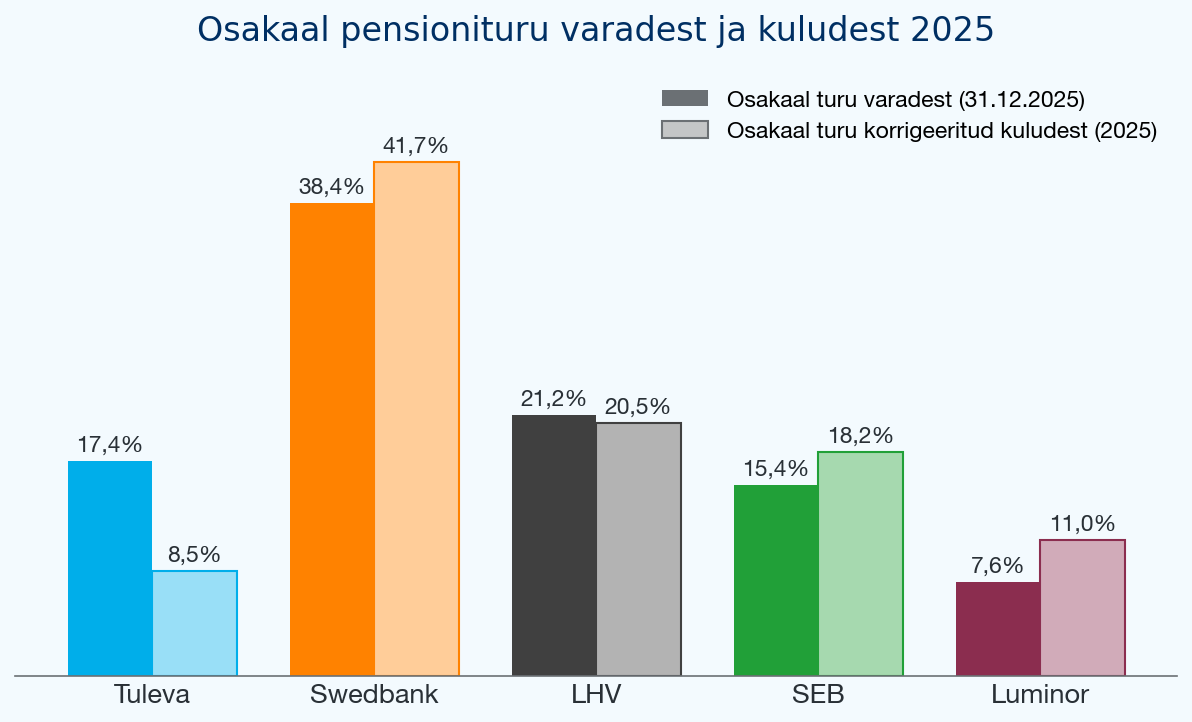

In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

# Tuleva brand styling (same palette as _regenerate_charts.py)
TULEVA_BLUE = '#00AEEA'
TEXT_PRIMARY = '#293036'
TEXT_SECONDARY = '#6B7074'
BG = '#f3fafe'

# Bank-specific colours (same as _regenerate_charts.py)
MANAGER_COLORS = {
    'Tuleva':   TULEVA_BLUE,
    'Swedbank': '#FF8200',
    'SEB':      '#21A038',
    'LHV':      '#404040',
    'Luminor':  '#8B2D4F',
}


def tint(color, f=0.6):
    """Blend a color toward white; f = share of white."""
    r, g, b = to_rgb(color)
    return (r + (1 - r) * f, g + (1 - g) * f, b + (1 - b) * f)


fonts_dir = Path.home() / 'Library' / 'Fonts'
for ttf in ['Roboto-Regular.ttf', 'Roboto-Medium.ttf', 'Roboto-Bold.ttf',
            'Merriweather-Variable.ttf', 'Merriweather[opsz,wdth,wght].ttf']:
    if (fonts_dir / ttf).exists():
        fm.fontManager.addfont(str(fonts_dir / ttf))
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Roboto', 'Helvetica Neue', 'Arial', 'DejaVu Sans']

# Shares of the whole market: AUM (section 2) vs adjusted costs (section 1)
aum_share = aum['KOKKU (€)'] / aum['KOKKU (€)'].sum() * 100
cost_share = expenses['Korrigeeritud KOKKU'] / expenses['Korrigeeritud KOKKU'].sum() * 100

share_df = pd.DataFrame({
    'varad': aum_share,
    'kulud': cost_share,
}).sort_values('varad', ascending=False)
share_df.index = [MANAGER_TOKENS[m] for m in share_df.index]

# Tuleva first, the rest stay in AUM order
share_df = share_df.reindex(['Tuleva'] + [m for m in share_df.index if m != 'Tuleva'])

fig, ax = plt.subplots(figsize=(10, 5.25), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

w = 0.38
for i, (mgr, row) in enumerate(share_df.iterrows()):
    color = MANAGER_COLORS[mgr]
    ax.bar(i - w / 2, row['varad'], w, color=color)
    ax.bar(i + w / 2, row['kulud'], w, color=tint(color), edgecolor=color, linewidth=1)
    for dx, val in ((-w / 2, row['varad']), (w / 2, row['kulud'])):
        ax.annotate(f'{val:.1f}%'.replace('.', ','),
                    (i + dx, val), xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=11, color=TEXT_PRIMARY)

ax.set_xticks(range(len(share_df)))
ax.set_xticklabels(share_df.index, fontsize=13)
ax.set_ylim(0, share_df.to_numpy().max() * 1.18)
ax.yaxis.set_visible(False)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(TEXT_SECONDARY)
ax.tick_params(axis='x', length=0, colors=TEXT_PRIMARY)

# Neutral legend: solid = assets, tinted = costs (each manager keeps its own hue)
legend_handles = [
    Patch(facecolor=TEXT_SECONDARY, label='Osakaal turu varadest (31.12.2025)'),
    Patch(facecolor=tint(TEXT_SECONDARY), edgecolor=TEXT_SECONDARY, linewidth=1,
          label='Osakaal turu korrigeeritud kuludest (2025)'),
]
ax.legend(handles=legend_handles, loc='upper right', frameon=False, fontsize=11)
ax.set_title('Osakaal pensionituru varadest ja kuludest 2025',
             fontsize=16, color='#002F63', pad=14, fontfamily='Merriweather')

CHARTS = Path('charts')
CHARTS.mkdir(exist_ok=True)
fig.savefig(CHARTS / 'chart-d-varade-kulude-osakaal-2025.png', bbox_inches='tight', dpi=150)
plt.show()